# Feature build — from raw CSV to a churn-ready feature table

Companion to `00_discovery.ipynb`. That notebook found the problems; this one shows how each finding
becomes a **decision**, and what the alternative would have cost.

```
RAW  ->  CLEANED  ->  FEATURES  ->  LABELLED TRAINING FRAME
 |         |            |             |
 |         |            |             `- 05_label.py
 |         |            `- 04_features.sql   (as_of_date parameterised)
 |         `- 03_clean.sql                   (one transform per Part 1 finding)
 `- 02_build_db.py                           (all TEXT, no constraints, nothing fixed)
```

The pipeline loads both CSVs into SQLite — built into Python — so the cleaning and feature logic can
be written as **reviewable SQL** rather than opaque dataframe chains. This notebook queries that same
database, so what you see below is the shipped logic, not a re-implementation of it.

In [1]:
import sqlite3, os, subprocess, sys
import pandas as pd, numpy as np

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

BASE = os.getcwd()
while not os.path.exists(os.path.join(BASE, "members.csv")) and BASE != os.path.dirname(BASE):
    BASE = os.path.dirname(BASE)
DB = os.path.join(BASE, "output", "loyalty.db")

def ensure_db():
    need = not os.path.exists(DB)
    if not need:
        c = sqlite3.connect(DB)
        have = {r[0] for r in c.execute(
            "SELECT name FROM sqlite_master WHERE type IN ('table','view')")}
        need = not {"clean_transactions", "churn_training"} <= have
        c.close()
    if need:
        print("building the database (run_all.sh does this too)...")
        for s in ("02_build_db.py", "03b_materialize.py", "05_label.py"):
            subprocess.run([sys.executable, os.path.join(BASE, "scripts", s)],
                           check=True, capture_output=True)
    return sqlite3.connect(DB)

con = ensure_db()
q = lambda sql: pd.read_sql_query(sql, con)
print(f"connected: {os.path.relpath(DB, BASE)}")

connected: output/loyalty.db


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Categorical palette -- validated for colour-vision deficiency separation
# (worst adjacent pair dE 9.2 deutan / 27.6 normal) against the #fcfcfb surface.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
BRAND_COLOR = {"PulseMart": BLUE, "PulseHome": ORANGE, "PulseEats": AQUA}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dcdbd6"

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb", "figure.dpi": 110,
    "font.size": 10, "text.color": INK,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlecolor": INK, "axes.titlepad": 10,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 8,
})

def clean_axes(ax, ygrid=True):
    """Recessive frame: no top/right spines, grid on one axis only."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis="y" if ygrid else "x")
    ax.grid(axis="x" if ygrid else "y", visible=False)
    return ax

print("chart style loaded")

chart style loaded


## Layer 1 — RAW is deliberately broken

Every column is `TEXT` and no constraints are applied. That is not laziness: the raw layer must be a
faithful reproduction of what landed, so every later transformation can be diffed against it. Coercing
types on load would turn the three date formats into nulls and destroy the evidence.

The load script prints the constraints that *would* fail today:

In [3]:
q('''SELECT 'raw_members.member_id' AS natural_key,
        (SELECT COUNT(*) FROM (SELECT member_id FROM raw_members
                               GROUP BY member_id HAVING COUNT(*)>1)) AS duplicated_values
     UNION ALL
     SELECT 'raw_transactions.transaction_id',
        (SELECT COUNT(*) FROM (SELECT transaction_id FROM raw_transactions
                               GROUP BY transaction_id HAVING COUNT(*)>1))''')

,natural_key,duplicated_values
0,raw_members.member_id,150
1,raw_transactions.transaction_id,1995


## Decision 1 — deduplication: `ROW_NUMBER()`, not `SELECT DISTINCT`

`SELECT DISTINCT` is the reflex. It only works if duplicate rows are *identical*. Checking first:

In [4]:
dup = q('''SELECT COUNT(*) AS dup_groups,
             SUM(CASE WHEN distinct_payloads = 1 THEN 1 ELSE 0 END) AS byte_identical,
             SUM(CASE WHEN distinct_payloads > 1 THEN 1 ELSE 0 END) AS conflicting
        FROM (SELECT transaction_id,
                     COUNT(DISTINCT member_id||'|'||transaction_date||'|'||amount||'|'||
                           points_earned||'|'||points_redeemed) AS distinct_payloads
              FROM raw_transactions GROUP BY transaction_id HAVING COUNT(*)>1)''')
display(dup)
print(f"SELECT DISTINCT would silently double-count the {int(dup.conflicting[0])} conflicting groups.")
print("ROW_NUMBER with a deterministic ORDER BY keeps exactly one row per id, and is")
print("stable across re-runs -- which matters, because non-determinism is a reproducibility bug.")

,dup_groups,byte_identical,conflicting
0,1995,1936,59


SELECT DISTINCT would silently double-count the 59 conflicting groups.
ROW_NUMBER with a deterministic ORDER BY keeps exactly one row per id, and is
stable across re-runs -- which matters, because non-determinism is a reproducibility bug.


## Decision 2 — sentinel amounts: NULL the value, keep the row

| option | effect |
|---|---|
| delete the row | biases *frequency* and *recency* down — the purchase did happen |
| winsorise to p99 | invents a price we have no basis for |
| **NULL the amount, keep the row** | `SUM`/`AVG` skip it; the row still counts toward frequency |

The third is why the feature SQL aggregates safely without special-casing anything:

In [5]:
q('''SELECT is_sentinel_amount, COUNT(*) AS rows, COUNT(amount) AS amount_not_null,
        ROUND(COALESCE(SUM(amount),0),2) AS spend_contributed
     FROM clean_transactions GROUP BY is_sentinel_amount''')

,is_sentinel_amount,rows,amount_not_null,spend_contributed
0,0,192301,192301,12387146.45
1,1,15,0,0.00


## Decision 3 — refunds: keep the row, reverse the points

2,012 rows carry a negative `amount` **and** positive `points_earned`, computed on `ABS(amount)`.
`ABS()` was the first suggestion and it launders a refund into a purchase. We keep the negative spend
(real, and exactly the behaviour a churn model should see) and zero the points the bug granted.

In [6]:
q('''SELECT is_refund, COUNT(*) AS rows, ROUND(SUM(amount),2) AS net_spend,
        ROUND(SUM(points_earned),0) AS points_kept,
        ROUND(SUM(points_reversed_on_refund),0) AS points_reversed
     FROM clean_transactions GROUP BY is_refund''')

,is_refund,rows,net_spend,points_kept,points_reversed
0,0,190321,12518492.74,25260611.0,0.0
1,1,1995,-131346.29,0.0,265569.0


## Decision 4 — null points: impute, but only because the rate is deterministic

Imputation is normally a smell. It is defensible **here and only here**, because the earn rate is not
an average — it is a constant. The rate is derived from the data, never hard-coded:

In [7]:
display(q("SELECT brand, earn_rate, n_rows FROM v_brand_earn_rate ORDER BY earn_rate DESC"))

grid = q('''SELECT m.tier,
        ROUND(SUM(CASE WHEN c.brand='PulseMart' THEN c.points_earned END)/
              SUM(CASE WHEN c.brand='PulseMart' THEN c.amount END),3) AS PulseMart,
        ROUND(SUM(CASE WHEN c.brand='PulseHome' THEN c.points_earned END)/
              SUM(CASE WHEN c.brand='PulseHome' THEN c.amount END),3) AS PulseHome,
        ROUND(SUM(CASE WHEN c.brand='PulseEats' THEN c.points_earned END)/
              SUM(CASE WHEN c.brand='PulseEats' THEN c.amount END),3) AS PulseEats
     FROM clean_transactions c JOIN clean_members m ON m.member_id=c.member_id
     WHERE c.is_sentinel_amount=0 AND c.is_refund=0 AND c.is_points_imputed=0
     GROUP BY m.tier''')
grid = grid.set_index("tier").loc[["Bronze", "Silver", "Gold", "Platinum"]]
display(grid)
print("Identical in every cell. Imputing amount * rate reproduces what the row would")
print("have carried, and every imputed row is flagged so a modeller can ablate them.")
print("\nIt is also a product finding: Platinum earns exactly what Bronze earns.")

,brand,earn_rate,n_rows
0,PulseMart,2.30,63353
1,PulseHome,2.00,62863
2,PulseEats,1.75,62594


,PulseMart,PulseHome,PulseEats
tier,,,
Bronze,2.3,2.0,1.75
Silver,2.3,2.0,1.75
Gold,2.3,2.0,1.75
Platinum,2.3,2.0,1.75


Identical in every cell. Imputing amount * rate reproduces what the row would
have carried, and every imputed row is flagged so a modeller can ablate them.

It is also a product finding: Platinum earns exactly what Bronze earns.


## The cleaning is reconciled, not silent

The rule the pipeline holds itself to: **every point removed must be accounted for.**

In [8]:
display(q("SELECT reason, n_rows, ROUND(points_removed,0) AS points_removed FROM clean_exclusions"))

raw = q("SELECT SUM(CASE WHEN trim(points_earned)='' THEN 0 ELSE CAST(points_earned AS REAL) END) v "
        "FROM raw_transactions").v[0]
rem = q("SELECT SUM(points_removed) v FROM clean_exclusions").v[0]
imp = q("SELECT SUM(points_earned) v FROM clean_transactions WHERE is_points_imputed=1").v[0]
cln = q("SELECT SUM(points_earned) v FROM clean_transactions WHERE is_orphan_member=0").v[0]
print(f"  raw      {raw:>14,.0f}")
print(f"  removed  {rem:>14,.0f}")
print(f"  imputed  {imp:>14,.0f}")
print(f"  clean    {cln:>14,.0f}")
print(f"\n  {raw:,.0f} - {rem:,.0f} + {imp:,.0f} = {raw-rem+imp:,.0f}   "
      f"{'RECONCILES' if abs(raw-rem+imp-cln) < 1 else 'MISMATCH'}")

,reason,n_rows,points_removed
0,duplicate_txn_rows,1995,261232.0
1,points_reversed_on_refund,1995,265569.0
2,orphan_member_rows,2988,388681.0
3,sentinel_amount_rows,15,0.0
4,unparseable_date_rows,0,0.0


  raw          25,586,688
  removed         915,482
  imputed         200,724
  clean        24,871,930

  25,586,688 - 915,482 + 200,724 = 24,871,930   RECONCILES


## The two-window frame

Features come from on-or-before a cutoff `T`; the label comes from the 90 days after it.
`T = 2026-04-01` is the last transaction date minus 90 days — the latest cutoff with a *complete*
outcome window.

```
|<------- observation window: features ------->|<-- outcome window: label -->|
2021-01-05                              T = 2026-04-01               2026-06-30
```

The same `04_features.sql` builds both frames. **Only the parameter changes** — that is what prevents
train/serve skew.

In [9]:
q('''SELECT 'features_train' AS frame, as_of_date, COUNT(*) AS members,
        MAX(last_txn_date) AS latest_data_seen FROM features_train GROUP BY as_of_date
     UNION ALL
     SELECT 'features_score', as_of_date, COUNT(*), MAX(last_txn_date)
     FROM features_score GROUP BY as_of_date''')

,frame,as_of_date,members,latest_data_seen
0,features_train,2026-04-01,39312,2026-04-01
1,features_score,2026-06-30,49996,2026-06-30


Note `latest_data_seen` on the training frame — no feature reaches past the cutoff.

### Why that bound is the whole design

Computed over *all* data, recency stops being a predictor and becomes a restatement of the label:

In [10]:
lk = q('''SELECT t.recency_days, t.churned_90d,
            CAST(julianday('2026-06-30') - julianday(s.last_txn_date) AS INT) AS recency_all_data
       FROM churn_training t JOIN features_score s ON s.member_id = t.member_id''')
print(f"corr(recency computed <= T,     label) = {lk.recency_days.corr(lk.churned_90d):.3f}   legitimate")
print(f"corr(recency computed over ALL, label) = {lk.recency_all_data.corr(lk.churned_90d):.3f}   leaks the answer")
print("\nA single careless MAX(transaction_date) yields a model that validates")
print("near-perfectly and is worthless in production.")

corr(recency computed <= T,     label) = 0.162   legitimate
corr(recency computed over ALL, label) = 0.760   leaks the answer

A single careless MAX(transaction_date) yields a model that validates
near-perfectly and is worthless in production.


## The feature table

In [11]:
train = q("SELECT * FROM churn_training")
skip = {"as_of_date", "member_id", "churned_90d", "last_txn_date"}
feats = [c for c in train.columns if c not in skip]
print(f"{len(feats)} features across {len(train):,} members   "
      f"| base rate {100*train.churned_90d.mean():.1f}% churned\n")
for i in range(0, len(feats), 3):
    print("   " + "".join(f"{c:<28s}" for c in feats[i:i+3]))

34 features across 31,712 members   | base rate 58.8% churned

   member_brand                tier                        country                     
   recency_days                tenure_days                 is_join_date_missing        
   is_join_date_future         txn_count_lifetime          txn_count_90d               
   txn_count_prev_90d          txn_count_365d              freq_trend_ratio            
   spend_trend_ratio           monetary_lifetime           avg_basket                  
   spend_90d                   spend_prev_90d              avg_gap_days                
   recency_vs_own_cadence      points_earned_total         points_redeemed_total       
   points_balance              redemption_rate             ever_redeemed_flag          
   distinct_brands             is_cross_brand              distinct_channels           
   pct_app                     tier_ambiguous_flag         has_imputed_points          
   has_sentinel_amount         has_refund                

In [12]:
train[["recency_days", "txn_count_lifetime", "monetary_lifetime",
       "points_balance", "redemption_rate", "avg_gap_days"]].describe().round(2)

,recency_days,txn_count_lifetime,monetary_lifetime,points_balance,redemption_rate,avg_gap_days
count,31712.00,31712.00,31712.00,31712.00,31695.00,29596.00
mean,120.30,4.07,277.68,512.90,0.11,199.38
std,98.92,1.84,205.70,415.34,0.17,177.90
min,0.00,1.00,-331.03,-200.00,0.00,0.00
25%,36.00,3.00,151.84,263.00,0.00,80.00
50%,95.00,4.00,242.24,437.00,0.00,156.00
75%,187.25,5.00,354.19,655.00,0.18,264.00
max,365.00,15.00,2267.27,4993.00,3.45,1790.00


## Validation — and the finding that changed the recommendation

Decile lift on recency: clean, near-monotonic separation.

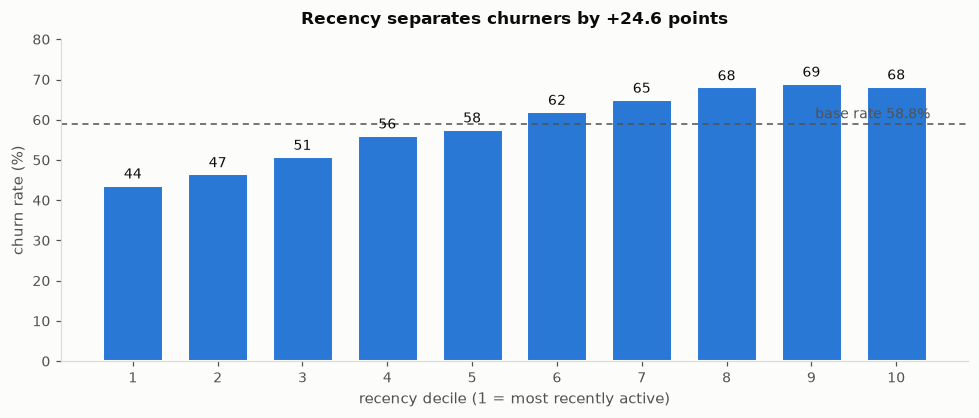

,n,churn,lo,hi
decile,,,,
1,3217,43.9,0,11
2,3277,46.7,12,28
3,3161,51.0,29,46
4,3074,56.3,47,68
5,3233,57.8,69,95
6,3115,62.2,96,126
7,3165,65.2,127,164
8,3192,68.3,165,214
9,3121,69.2,215,278


In [13]:
d = train.dropna(subset=["recency_days"]).copy()
d["decile"] = pd.qcut(d.recency_days, 10, labels=False, duplicates="drop") + 1
lift = d.groupby("decile").agg(n=("churned_90d", "size"),
                               churn=("churned_90d", "mean"),
                               lo=("recency_days", "min"), hi=("recency_days", "max"))
lift["churn"] = (100 * lift.churn).round(1)

fig, ax = plt.subplots(figsize=(9, 3.9))
bars = ax.bar(lift.index, lift.churn, color=BLUE, edgecolor="#fcfcfb", linewidth=2, width=0.72)
for b, v in zip(bars, lift.churn):
    ax.annotate(f"{v:.0f}", (b.get_x()+b.get_width()/2, v), (0, 4), textcoords="offset points",
                ha="center", fontsize=9, color=INK)
clean_axes(ax)
ax.axhline(100*train.churned_90d.mean(), color=INK2, linewidth=1, linestyle=(0, (4, 3)))
ax.annotate(f"base rate {100*train.churned_90d.mean():.1f}%", (10.4, 100*train.churned_90d.mean()),
            (0, 4), textcoords="offset points", ha="right", color=INK2, fontsize=9)
ax.set_xticks(range(1, 11)); ax.set_xlabel("recency decile (1 = most recently active)")
ax.set_ylabel("churn rate (%)"); ax.set_ylim(0, 80)
ax.set_title(f"Recency separates churners by {lift.churn.iloc[-1]-lift.churn.iloc[0]:+.1f} points")
plt.tight_layout(); plt.show()
display(lift)

,feature,corr,expected,actual,verdict
3,txn_count_90d,-0.206,-,-,ok
4,freq_trend_ratio,-0.148,-,-,ok
2,recency_vs_own_cadence,-0.055,+,-,INVERTED
8,ever_redeemed_flag,0.044,-,+,INVERTED
9,is_cross_brand,0.053,-,+,INVERTED
0,recency_days,0.162,+,+,ok
7,points_balance,0.175,-,+,INVERTED
6,monetary_lifetime,0.181,-,+,INVERTED
5,txn_count_lifetime,0.202,-,+,INVERTED
1,avg_gap_days,0.209,+,+,ok


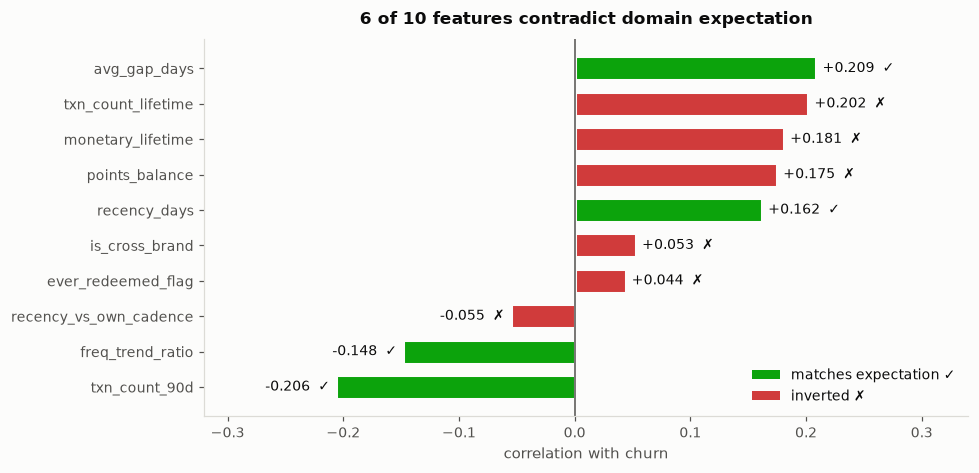

6 inverted: recency_vs_own_cadence, ever_redeemed_flag, is_cross_brand, points_balance, monetary_lifetime, txn_count_lifetime

All of them accumulate VOLUME. Root cause is 00_discovery.ipynb Catch 3:
corr(txns before cutoff, txns after) is NEGATIVE, so observed volume is
anti-predictive here. Recommendation: ship the recency/trend family, block the
volume family pending an explanation from whoever generates this data.


In [14]:
# the directional check -- does each feature behave the way domain knowledge expects?
# same ten features, same expected signs, as the table in answers/part2-features.md
expect = {"recency_days": "+", "avg_gap_days": "+", "recency_vs_own_cadence": "+",
          "txn_count_90d": "-", "freq_trend_ratio": "-", "txn_count_lifetime": "-",
          "monetary_lifetime": "-", "points_balance": "-", "ever_redeemed_flag": "-",
          "is_cross_brand": "-"}
rows = []
for f, e in expect.items():
    s = train[[f, "churned_90d"]].dropna()
    c = s[f].corr(s.churned_90d)
    rows.append({"feature": f, "corr": round(c, 3), "expected": e,
                 "actual": "+" if c > 0 else "-",
                 "verdict": "ok" if ("+" if c > 0 else "-") == e else "INVERTED"})
chk = pd.DataFrame(rows).sort_values("corr")
display(chk)

GOOD, CRITICAL = "#0ca30c", "#d03b3b"
fig, ax = plt.subplots(figsize=(9, 4.4))
colors = [GOOD if v == "ok" else CRITICAL for v in chk.verdict]
bars = ax.barh(chk.feature, chk["corr"], color=colors, edgecolor="#fcfcfb", linewidth=2, height=0.68)
for b, v, verdict in zip(bars, chk["corr"], chk.verdict):
    off = 4 if v >= 0 else -4
    ax.annotate(f"{v:+.3f}" + ("  ✗" if verdict == "INVERTED" else "  ✓"),
                (v, b.get_y()+b.get_height()/2), (off, 0), textcoords="offset points",
                va="center", ha="left" if v >= 0 else "right", fontsize=9, color=INK)
clean_axes(ax, ygrid=False)
ax.axvline(0, color=INK2, linewidth=1)
ax.set_xlim(-0.32, 0.34); ax.set_xlabel("correlation with churn")
n_bad = int((chk.verdict == "INVERTED").sum())
ax.set_title(f"{n_bad} of {len(chk)} features contradict domain expectation")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=GOOD, label="matches expectation ✓"),
                   Patch(facecolor=CRITICAL, label="inverted ✗")], loc="lower right")
plt.tight_layout(); plt.show()

bad = list(chk.loc[chk.verdict == "INVERTED", "feature"])
print(f"{len(bad)} inverted: " + ", ".join(bad))
print("\nAll of them accumulate VOLUME. Root cause is 00_discovery.ipynb Catch 3:")
print("corr(txns before cutoff, txns after) is NEGATIVE, so observed volume is")
print("anti-predictive here. Recommendation: ship the recency/trend family, block the")
print("volume family pending an explanation from whoever generates this data.")

The colour here carries a verdict, so it is paired with a ✓/✗ glyph and the `verdict` column above —
never colour alone.

---

The hardened, assertion-backed version of every check in this notebook is `scripts/06_validate.py`.
Run `bash run_all.sh` to rebuild everything from the two CSVs.

In [15]:
con.close()
print("done")

done
